# Introudction
This notebook shows how to open and understand the dataset.
It also shows how to prepare the results submission.
You can run this script as a Python script or as a Jupyter notebook.

In [1]:
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

Dataset paths

In [3]:
DATASET_DIR = Path('./data')

In [4]:
HSI_AIRBORNE_DIR = DATASET_DIR / 'train' / 'hsi_airborne'
HSI_SATELLITE_DIR = DATASET_DIR / 'train' / 'hsi_satellite'
MSI_SATELLITE_TRAIN_DIR = DATASET_DIR / 'train' / 'msi_satellite'
MSI_SATELLITE_TEST_DIR = DATASET_DIR / 'test' / 'msi_satellite'

In [5]:
GT_TRAIN_CSV_PATH = DATASET_DIR / 'train_gt.csv'
# %% Load the ground truth measurements
gt_train_df = pd.read_csv(GT_TRAIN_CSV_PATH)
gt_train_df.head()
column_names = ['Fe', 'Zn', 'B', 'Cu', 'S', 'Mn']

`gt_df` contains the ground truth measurements for the training dataset.
For each sample_index we have 6 ground-truth measurements: Fe, Zn, B, Cu, S, Mn.

# Dsiplaying example data
One field for a single multispectral band, for all 3 modalities.

In [6]:
import matplotlib.pyplot as plt
import numpy as np

selected_index = 67
BAND_NUMBER = 7

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="lightgray")

# HSI Airborne
with np.load(HSI_AIRBORNE_DIR / f"{selected_index:04}.npz") as npz:
    arr = np.ma.MaskedArray(**npz)

plt.figure(figsize=(5, 5))
plt.imshow(arr[BAND_NUMBER], cmap=cmap)
plt.xticks([])
plt.yticks([])
plt.savefig("hsi_airborne.pdf", bbox_inches="tight", pad_inches=0)
plt.close()

# HSI Satellite
with np.load(HSI_SATELLITE_DIR / f"{selected_index:04}.npz") as npz:
    arr = np.ma.MaskedArray(**npz)

plt.figure(figsize=(5, 5))
plt.imshow(arr[BAND_NUMBER].data, cmap=cmap)  # no .data
plt.xticks([])
plt.yticks([])
plt.savefig("hsi_satellite.pdf", bbox_inches="tight", pad_inches=0)
plt.close()

# MSI Satellite
with np.load(MSI_SATELLITE_TRAIN_DIR / f"{selected_index:04}.npz") as npz:
    arr = np.ma.MaskedArray(**npz)

plt.figure(figsize=(5, 5))
plt.imshow(arr[BAND_NUMBER], cmap=cmap)
plt.xticks([])
plt.yticks([])
plt.savefig("msi_satellite.pdf", bbox_inches="tight", pad_inches=0)
plt.close()

97.3 481.7 216.3089552238806
179.2 204.05 237.225


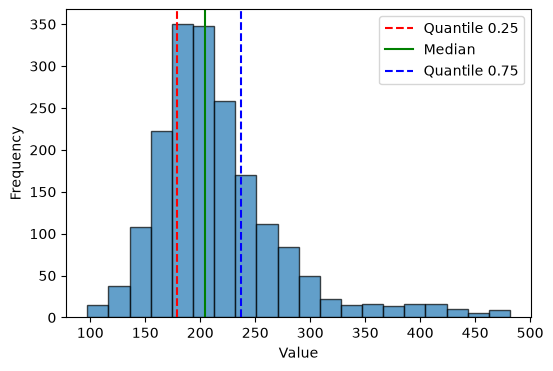

1.5 14.4 4.849147121535181
3.5 4.5 6.0


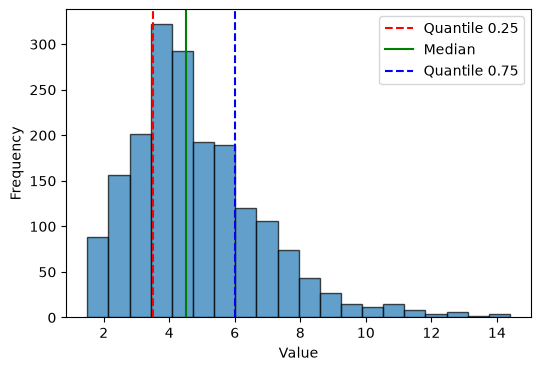

0.3 1.9 0.8538379530916844
0.7000000000000001 0.8 1.0


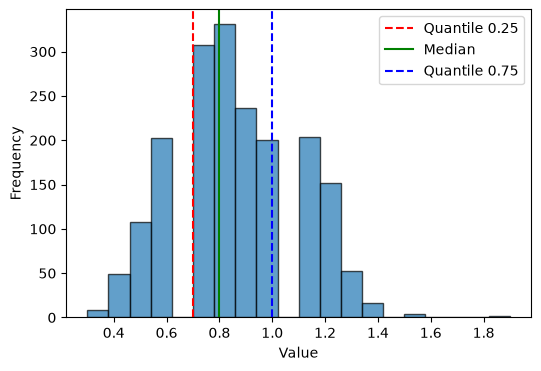

1.6 4.3 2.587100213219616
2.3 2.5 2.8


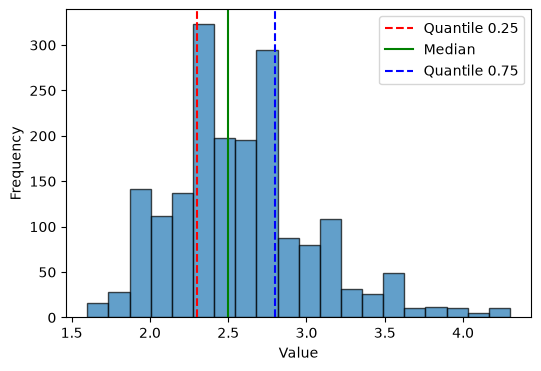

6.7133779365 96.8092647002 26.473430577582516
17.1005702002 24.871994424649998 32.1882949813


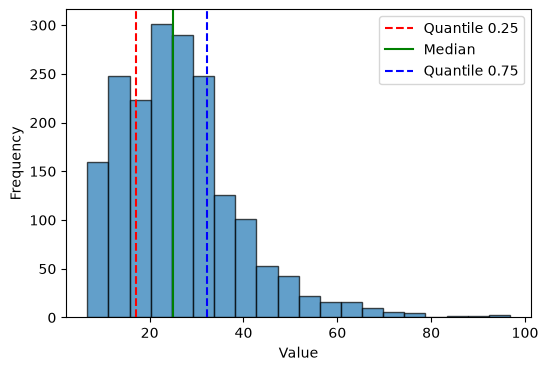

21.3 167.6 89.39456289978678
74.0 87.4 102.9


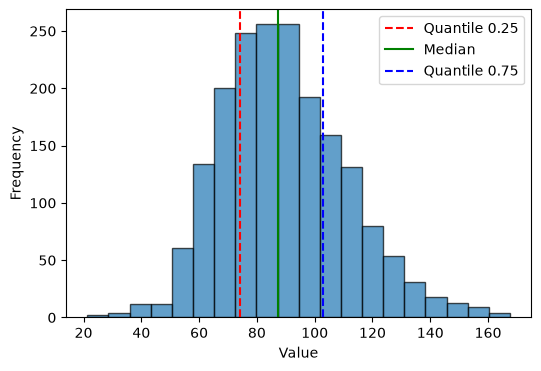

In [7]:
import matplotlib.pyplot as plt

df_subset = gt_train_df[column_names]

full_names = {
    "Fe": "Żelazo",
    "Zn": "Cynk",
    "B": "Bor",
    "Cu": "Miedź",
    "S": "Siarka",
    "Mn": "Mangan"
}

for col in column_names:
    plt.figure(figsize=(6, 4))

    # Histogram
    plt.hist(df_subset[col], bins=20, edgecolor='black', alpha=0.7)

    # Quantiles
    plt.axvline(df_subset[col].quantile(0.25), color='red', linestyle='--', label='Quantile 0.25')
    plt.axvline(df_subset[col].median(), color='green', linestyle='-', label='Median')
    plt.axvline(df_subset[col].quantile(0.75), color='blue', linestyle='--', label='Quantile 0.75')

    # Debug prints
    print(df_subset[col].min(), df_subset[col].max(), df_subset[col].mean())
    print(df_subset[col].quantile(0.25), df_subset[col].median(), df_subset[col].quantile(0.75))

    plt.xlabel('Value')
    plt.ylabel('Frequency')

    plt.legend()

    # ✅ Save correctly
    plt.savefig(f'{full_names[col]}.pdf', bbox_inches='tight')
    plt.show()

    plt.close()  # better than show() when saving many plots

# Checking resolution range for each source type

# Displaying spectral curve for a selected field

In [8]:
selected_index = 377

In [9]:
with np.load(HSI_SATELLITE_DIR / f'{selected_index:04}.npz') as npz:
    arr = np.ma.MaskedArray(**npz)

In [10]:
pixel_0 = arr.data[:, 0, 0]

Text(0.5, 1.0, 'Spectral curve for a selected pixel')

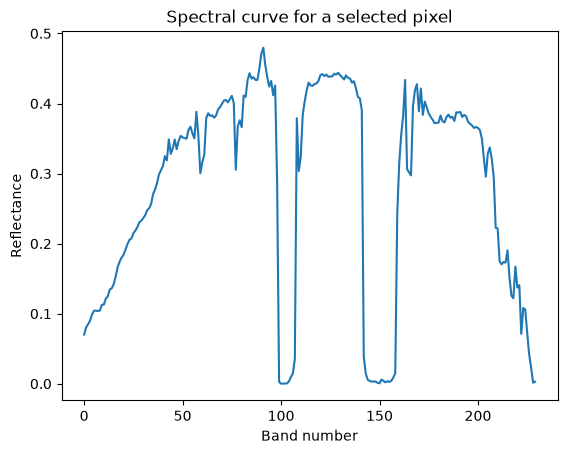

In [11]:
plt.plot(pixel_0)
plt.xlabel('Band number')
plt.ylabel('Reflectance')
plt.title('Spectral curve for a selected pixel')

%% [markdown]


<br>
# Generating baseline solution<br>
Baseline solution is used to calculate the performance of the final model.<br>


In [12]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0
    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self
    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)

%% [markdown]


<br>
# Load data for satellite multispectral images<br>


In [13]:
def load_msi_data(directory):
    files = sorted(directory.glob('*.npz'))
    msi_data = []
    for file in enumerate(files):
        file_name = file[1]
        with np.load(file_name) as npz:
            arr = np.ma.MaskedArray(**npz)
            mean_pixel = np.mean(arr, axis=(1, 2))  # mean over all pixels
            msi_data.append(mean_pixel)
    msi_data = np.array(msi_data)
    return msi_data

In [14]:
print(f'Loading data from {MSI_SATELLITE_TRAIN_DIR} and {MSI_SATELLITE_TEST_DIR}')
X_train_all = load_msi_data(MSI_SATELLITE_TRAIN_DIR)
X_test_all = load_msi_data(MSI_SATELLITE_TEST_DIR)
y_train_all = gt_train_df[column_names].values

Loading data from data/train/msi_satellite and data/test/msi_satellite


In [15]:
print(f'X_train shape: {X_train_all.shape}')
print(f'Y_train shape: {y_train_all.shape}')
print(f'X_test shape: {X_test_all.shape}')

X_train shape: (1876, 12)
Y_train shape: (1876, 6)
X_test shape: (1888, 12)


%% [markdown]


<br>
# Calculating the metric<br>
Use part of the training data to train the model and the rest to calculate the metric.<br>


In [16]:
X_train = X_train_all[:1300]
y_train = y_train_all[:1300]

In [17]:
X_test = X_train_all[1300:]
y_test = y_train_all[1300:]

Fit the baseline model

In [18]:
baseline_reg = BaselineRegressor()
baseline_reg = baseline_reg.fit(X_train, y_train)
baseline_predictions = baseline_reg.predict(X_test)

Generate baseline values to be used in score computation

In [19]:
baselines = np.mean((y_test - baseline_predictions) ** 2, axis=0)

Generate predictions slightly different from baseline predictions

In [20]:
np.random.seed(0)
predictions = np.zeros_like(y_test)
for column_index in range(predictions.shape[1]):
    class_mean_value = baseline_reg.mean[column_index]
    predictions[:, column_index] = np.random.uniform(low=class_mean_value - class_mean_value * 0.2,
                                                     high=class_mean_value + class_mean_value * 0.2,
                                                     size=len(predictions))

Calculate MSE for each class

In [21]:
mse = np.mean((y_test - predictions) ** 2, axis=0)

Calculate the score for each class individually

In [22]:
scores = mse / baselines

Calculate the final score

In [23]:
final_score = np.mean(scores)

In [24]:
for score, class_name in zip(scores, column_names):
    print(f"Class {class_name} score: {score}")

Class Fe score: 1.157426856706684
Class Zn score: 1.059032793104139
Class B score: 1.1648081081649437
Class Cu score: 1.491160760393519
Class S score: 1.026155672977328
Class Mn score: 1.2956695787511288


In [25]:
print(f"Final score: {final_score}")

Final score: 1.1990422950162907


%% [markdown]


<br>
# Prepare the submission for test set<br>


In [26]:
baseline_predictions_test = baseline_reg.predict(X_test_all)
submission = pd.DataFrame(data=baseline_predictions_test, columns=column_names)
submission.to_csv("submission.csv", index_label="sample_index")

%%